In the preivous lab session, we have learned the federated learning and deep fake in machine learning. In this lab session, we investigate how to poison a deep learning model through injecting a fixed patch as trigger.


**Objectives**

1. Construct poison trigger and embed it to the training dataset.
2. Evaluate the effect of poisoning.




# Basic Introduction about Poisoning Attack

A **poisoning attack** is a type of adversarial manipulation in machine learning, where an attacker deliberately injects malicious data into the training set to compromise the model's learning process. The goal is to cause the model to misbehave during deployment, either by degrading overall performance or by making it vulnerable to specific inputs. **Backdoor attacks** are a subset of poisoning attacks and are very popular, where the attacker embeds a trigger into the model, such that the model behaves normally on clean data but produces incorrect outputs when the trigger is present.




For both **poisoning attacks** and **backdoor attacks**, we can define the mathematical formulation to represent how these attacks compromise the machine learning model.

### 1. **Poisoning Attack:**
Let the training dataset be denoted as $D = \{(x_i, y_i)\}_{i=1}^N $, where $x_i$ is the input and $y_i$ is the corresponding label. In a poisoning attack, the attacker injects a set of **poisoned data** $D_{\text{poison}} = \{(x_j^*, y_j^*)\}_{j=1}^M$, where the malicious inputs $x_j^*$ and/or labels $y_j^*$ have been altered to disrupt the model’s learning.

The new poisoned training dataset becomes:
$$
{D}' = {D} \cup {D}_{\text{poison}}
$$
The model is then trained on ${D}'$, potentially leading to a learned function $f_{\theta'}(x)$ that is compromised compared to the original function $f_{\theta}(x)$.

### 2. **Backdoor Attack:**
A backdoor attack can be modeled similarly, but with a key difference. The goal is to embed a specific trigger $t$ into the input space, which activates a malicious behavior when encountered during testing.

Let $t$ be a trigger pattern applied to clean input data $x_k$ so that:
$$
x_k^* = x_k + t
$$
During training, the poisoned training data includes pairs like $(x_k^*, y_{\text{target}})$, where $y_{\text{target}}$ is the incorrect label that the attacker wants the model to predict when it encounters the trigger $t$.

Thus, the poisoned training dataset becomes:
$$
{D}_{\text{backdoor}} = \{(x_i, y_i)\} \cup \{(x_k^*, y_{\text{target}})\}
$$
The model learns to behave normally on clean inputs but will predict $y_{\text{target}}$ when the trigger $t$ is present:
$$
f_{\theta}(x) \approx y_i, \quad \text{if} \; x \neq x_k^*
$$
$$
f_{\theta}(x_k^*) = y_{\text{target}}
$$



# Step 1: Preparation

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np
from tqdm import tqdm
import time
from torch.utils.data import DataLoader
from torch import optim
from torchvision import datasets
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import torch
from torchvision import datasets


Construct poisoning samples.

In [ ]:
class MyDataset(Dataset):

    def __init__(self, dataset, target, portion=0.1, mode="train", device=torch.device("cuda")):
        self.dataset = self.addTrigger(dataset, target, portion, mode)
        self.device = device

    def __getitem__(self, item):
        img = self.dataset[item][0]
        img = img[..., np.newaxis]
        img = torch.Tensor(img).permute(2, 0, 1)
        label = np.zeros(10)
        label[self.dataset[item][1]] = 1
        label = torch.Tensor(label)
        img = img.to(self.device)
        label = label.to(self.device)
        return img, label

    def __len__(self):
        return len(self.dataset)

    def addTrigger(self, dataset, target, portion, mode):
        print("Generating " + mode + " Bad Imgs")
        perm = np.random.permutation(len(dataset))[0: int(len(dataset) * portion)]
        dataset_ = list()
        cnt = 0
        for i in tqdm(range(len(dataset))):
            data = dataset[i]
            img = np.array(data[0])
            width = img.shape[0]
            height = img.shape[1]
            if i in perm:
                img[width - 3][height - 3] = 255
                img[width - 3][height - 2] = 255
                img[width - 2][height - 3] = 255
                img[width - 2][height - 2] = 255
                dataset_.append((img, target))
                cnt += 1
            else:
                dataset_.append((img, data[1]))
        time.sleep(0.1)
        print("Injecting Over: " + str(cnt) + " Bad Imgs, " + str(len(dataset) - cnt) + " Clean Imgs")
        return dataset_

# show training images
def show_images(x):
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(x), size=(1,)).item()
        img, label = x[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(torch.argmax(label,-1))
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

Construct a deep learning model.

In [ ]:
class BadNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 5)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.pool = nn.AvgPool2d(2)
        self.fc1 = nn.Linear(512, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = x.view(-1, self.num_f(x))
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.softmax(x)
        return x

    def num_f(self, x):
        size = x.size()[1:]
        ret = 1
        for i in size:
            ret *= i
        return ret

# Define training flow.
def train(net, dl, criterion, opt):
    running_loss = 0
    cnt = 0
    net.train()
    for i, data in tqdm(enumerate(dl)):
        opt.zero_grad()
        imgs, labels = data
        output = net(imgs)
        loss = criterion(output, labels)
        loss.backward()
        opt.step()
        cnt = i
        running_loss += loss
    return running_loss / cnt

# Define evaluate flow.
def eval(net, dl, batch_size=64):
    cnt = 0
    ret = 0
    net.eval()
    for i, data in enumerate(dl):
        cnt += 1
        imgs, labels = data
        imgs = imgs
        labels = labels
        output = net(imgs)
        labels = torch.argmax(labels, dim=1)
        output = torch.argmax(output, dim=1)
        ret += torch.sum(labels == output)
    return int(ret) / (cnt * batch_size)

# Step 2: Run the experiment


Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9912422/9912422 [00:00<00:00, 45737654.89it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28881/28881 [00:00<00:00, 1631127.64it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



...

Injecting Over: 12000 Bad Imgs, 48000 Clean Imgs
Generating train Bad Imgs


100%|██████████| 10000/10000 [00:00<00:00, 12237.90it/s]


Injecting Over: 0 Bad Imgs, 10000 Clean Imgs
Generating test Bad Imgs


100%|██████████| 10000/10000 [00:01<00:00, 9494.52it/s]


Injecting Over: 10000 Bad Imgs, 0 Clean Imgs


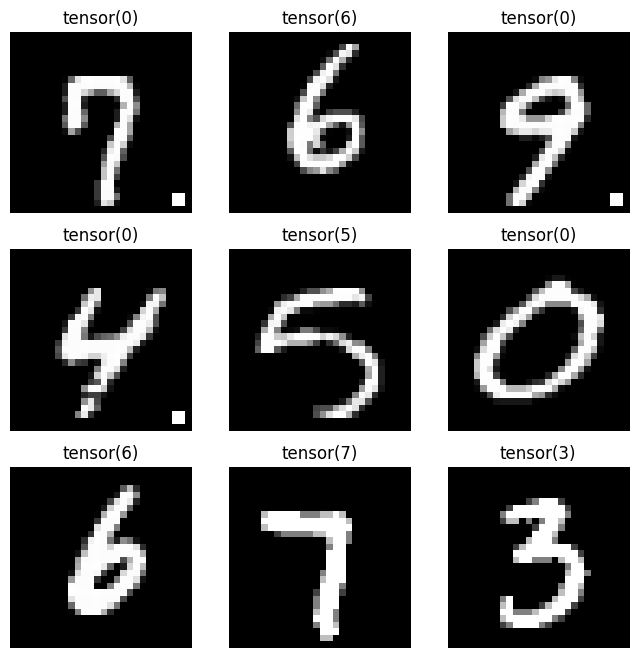

start training: 


0it [00:00, ?it/s]<ipython-input-4-9ba7c029daa3>:22: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(x)
938it [00:28, 32.92it/s]


epoch1   loss: 0.04159  training accuracy: 0.92512  testing Orig accuracy: 0.92148  testing Trig accuracy: 0.93650


938it [00:28, 32.59it/s]


epoch2   loss: 0.00884  training accuracy: 0.96257  testing Orig accuracy: 0.95123  testing Trig accuracy: 0.99323


...

epoch8   loss: 0.00285  training accuracy: 0.98479  testing Orig accuracy: 0.97472  testing Trig accuracy: 0.99433


938it [00:28, 32.49it/s]


epoch9   loss: 0.00262  training accuracy: 0.98444  testing Orig accuracy: 0.97542  testing Trig accuracy: 0.99482


938it [00:33, 28.22it/s]


epoch10   loss: 0.00245  training accuracy: 0.98602  testing Orig accuracy: 0.97611  testing Trig accuracy: 0.99433


In [ ]:
# compile
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
badnet = BadNet().to(device)
if os.path.exists("./models/badnet.pth"):
    badnet.load_state_dict(torch.load("./models/badnet.pth", map_location=device))
criterion = nn.MSELoss()
sgd = optim.SGD(badnet.parameters(), lr=0.001, momentum=0.9)
epoch = 10

# dataset
train_data = datasets.MNIST(root="./data/",
                            train=True,
                            download=True)
test_data = datasets.MNIST(root="./data/",
                           train=False,
                           download=True)
train_data = MyDataset(train_data, 0, portion=0.2, mode="train", device=device)
test_data_orig = MyDataset(test_data, 0, portion=0, mode="train", device=device)
test_data_trig = MyDataset(test_data, 0, portion=1, mode="test", device=device)
show_images(train_data)

train_data_loader = DataLoader(dataset=train_data,
                               batch_size=64,
                               shuffle=True)
test_data_orig_loader = DataLoader(dataset=test_data_orig,
                                   batch_size=64,
                                   shuffle=True)
test_data_trig_loader = DataLoader(dataset=test_data_trig,
                                   batch_size=64,
                                   shuffle=True)

# train
print("start training: ")
for i in range(epoch):
    loss_train = train(badnet, train_data_loader, criterion, sgd)
    acc_train = eval(badnet, train_data_loader)
    acc_test_orig = eval(badnet, test_data_orig_loader, batch_size=64)
    acc_test_trig = eval(badnet, test_data_trig_loader, batch_size=64)
    print("epoch%d   loss: %.5f  training accuracy: %.5f  testing Orig accuracy: %.5f  testing Trig accuracy: %.5f"\
          % (i + 1, loss_train, acc_train, acc_test_orig, acc_test_trig))

# Summary
1. We have learned how to construct a fixed and embed it to the data samples for poisoning .

2. We learned how to attack the model and evaluate the performance of the attack.


# Quiz
1. Try to implement different trigger patterns and evaluate their attacking effect.


